# Projeto de Teste A/B — Sistema de Recomendação

Análise do teste `recommender_system_test` de uma loja online internacional.
O teste foi conduzido por um analista anterior, que deixou apenas as especificações
técnicas e os dados brutos. O objetivo aqui é **validar se o teste foi conduzido
corretamente** antes de avaliar seus resultados via z-test.

## Passo 1 — Objetivos do estudo

O teste `recommender_system_test` avalia a introdução de um **sistema de recomendação
melhorado** em uma loja online internacional.

**Hipótese de negócio:** em até **14 dias após o cadastro**, usuários do grupo B
(novo funil) apresentam conversão superior à do grupo A (controle) em cada etapa
do funil `product_page → product_cart → purchase`, com ganho de **pelo menos 10%**
em cada etapa.

**Objetivo desta análise:**
1. Validar se o teste foi conduzido corretamente (desenho, balanceamento, contaminação).
2. Avaliar, via z-test, se o grupo B de fato supera o A nas conversões.

**Parâmetros da especificação:**
- Público: 15% dos novos usuários da região da UE
- Captação: 07/12/2020 a 21/12/2020 · Término: 01/01/2021
- Participantes esperados: ~6000

## Passo 2 — Carregamento e inspeção inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

marketing    = pd.read_csv('ab_project_marketing_events_us.csv')
new_users    = pd.read_csv('final_ab_new_users_upd_us.csv')
events       = pd.read_csv('final_ab_events_upd_us.csv')
participants = pd.read_csv('final_ab_participants_upd_us.csv')

print('marketing   ', marketing.shape)
print('new_users   ', new_users.shape)
print('events      ', events.shape)
print('participants', participants.shape)

marketing    (14, 4)
new_users    (58703, 4)
events       (423761, 4)
participants (14525, 3)


In [2]:
for name, df in [('marketing', marketing), ('new_users', new_users),
                 ('events', events), ('participants', participants)]:
    print(f'===== {name} =====')
    df.info()
    print(df.head(3), '\n')

===== marketing =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes
                           name                   regions    start_dt  \
0      Christmas&New Year Promo             EU, N.America  2020-12-25   
1  St. Valentine's Day Giveaway  EU, CIS, APAC, N.America  2020-02-14   
2        St. Patric's Day Promo             EU, N.America  2020-03-17   

    finish_dt  
0  2021-01-03  
1  2020-02-16  
2  2020-03-19   

===== new_users =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-n

## Passo 3 — Tipagem, valores ausentes e duplicados

In [3]:
# --- Tipagem: datas → datetime ---
marketing['start_dt']   = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt']  = pd.to_datetime(marketing['finish_dt'])
new_users['first_date'] = pd.to_datetime(new_users['first_date'])
events['event_dt']      = pd.to_datetime(events['event_dt'])

# --- Duplicados (linhas inteiras) ---
for name, df in [('marketing', marketing), ('new_users', new_users),
                 ('events', events), ('participants', participants)]:
    print(f'{name:>14} → duplicados: {df.duplicated().sum()}')

print()

# --- Caracterizar os nulos de 'details' ---
# Hipótese: 'details' só é preenchido em eventos 'purchase'.
print('Eventos COM details preenchido:', events.loc[events['details'].notna(), 'event_name'].unique())
print('\nContagem por tipo de evento:')
print(events['event_name'].value_counts())

     marketing → duplicados: 0
     new_users → duplicados: 0
        events → duplicados: 0
  participants → duplicados: 0

Eventos COM details preenchido: ['purchase']

Contagem por tipo de evento:
login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: event_name, dtype: int64


### Decisões do Passo 3

- **Tipagem:** `start_dt`, `finish_dt`, `first_date` e `event_dt` convertidas para `datetime`.
- **Duplicados:** nenhum encontrado nos quatro datasets.
- **Ausentes:** apenas `details` (em `events`) contém nulos, e isso é **estrutural** —
  o campo só é preenchido em eventos `purchase`. **Decisão `[autoral]`: manter os nulos**,
  pois representam ausência legítima de valor monetário em eventos de navegação
  (apagá-los descartaria ~86% dos eventos).
- **Observação para a AED:** `purchase` (60.314) > `product_cart` (60.120), logo o funil
  **não é estritamente sequencial** (há compra sem passagem registrada pelo carrinho).

## Passo 4 — Validação do desenho do teste

In [4]:
# Quais testes existem na tabela de participantes?
print('Testes presentes:')
print(participants['ab_test'].value_counts(), '\n')

# Isola o nosso teste
rec_sys_test = participants[participants['ab_test'] == 'recommender_system_test'].copy()

# Headcount e balanceamento dos grupos
print('Participantes do recommender_system_test:', len(rec_sys_test))
print('\nDistribuição por grupo:')
print(rec_sys_test['group'].value_counts())

Testes presentes:
interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64 

Participantes do recommender_system_test: 3675

Distribuição por grupo:
A    2747
B     928
Name: group, dtype: int64


In [5]:
# Usuários que estão em MAIS DE UM teste (contaminação cruzada)
tests_per_user = participants.groupby('user_id')['ab_test'].nunique()
multi_test = tests_per_user[tests_per_user > 1].index
print('Usuários em mais de um teste:', len(multi_test))

# Desses, quantos estão no NOSSO teste?
contaminated = rec_sys_test[rec_sys_test['user_id'].isin(multi_test)]
print('Participantes do recommender que também estão em outro teste:', len(contaminated))

# Usuário que aparece em A E B do nosso teste ao mesmo tempo (erro grave de alocação)
groups_per_user = rec_sys_test.groupby('user_id')['group'].nunique()
in_two_groups = groups_per_user[groups_per_user > 1]
print('\nUsuários do recommender em A e B simultaneamente:', len(in_two_groups))

Usuários em mais de um teste: 887
Participantes do recommender que também estão em outro teste: 887

Usuários do recommender em A e B simultaneamente: 0


In [6]:
# Remove os contaminados → base limpa do teste
rec_sys_test_clean = rec_sys_test[~rec_sys_test['user_id'].isin(multi_test)].copy()

print('Antes da limpeza:', len(rec_sys_test))
print('Depois da limpeza:', len(rec_sys_test_clean))
print('\nDistribuição por grupo (limpa):')
print(rec_sys_test_clean['group'].value_counts())

Antes da limpeza: 3675
Depois da limpeza: 2788

Distribuição por grupo (limpa):
A    2082
B     706
Name: group, dtype: int64


### Validação do desenho — achados

- **Headcount:** 3675 participantes no `recommender_system_test` (spec esperava ~6000 → 39% abaixo).
- **Contaminação cruzada:** 887 usuários (24%) também participam do `interface_eu_test`,
  rodando no mesmo período e público (UE). Exposição dupla impede atribuir efeito ao
  recomendador. **Decisão `[autoral]`: removidos.**
- **Base limpa:** 2788 participantes (54% abaixo da spec).
- **Desbalanceamento:** A=2082 (75%) vs B=706 (25%) — persiste após a limpeza, logo é da
  alocação original, não da contaminação. Proporção atípica para um A/B test.
- **Alocação interna:** nenhum usuário em A e B simultaneamente (ok).

In [7]:
# Junta os participantes limpos com os dados de cadastro (região + data)
base = rec_sys_test_clean.merge(new_users, on='user_id', how='left')

# (a) REGIÃO — todos são da UE?
print('Regiões dos participantes:')
print(base['region'].value_counts(dropna=False), '\n')

# (b) JANELA DE 14 DIAS
print('Cadastro — mínimo:', base['first_date'].min())
print('Cadastro — máximo:', base['first_date'].max())
print('Último evento disponível:', events['event_dt'].max())

Regiões dos participantes:
EU           2594
N.America     119
APAC           45
CIS            30
Name: region, dtype: int64 

Cadastro — mínimo: 2020-12-07 00:00:00
Cadastro — máximo: 2020-12-21 00:00:00
Último evento disponível: 2020-12-30 23:36:33


In [8]:
# Mantém só UE (alinhado à spec)
base = base[base['region'] == 'EU'].copy()

print('Headcount final (UE, sem contaminação):', len(base))
print('\nDistribuição por grupo:')
print(base['group'].value_counts())

Headcount final (UE, sem contaminação): 2594

Distribuição por grupo:
A    1939
B     655
Name: group, dtype: int64


### Funil de filtragem da amostra `[autoral]`

Decisões de filtragem aplicadas (remover contaminados, restringir à UE):

| Etapa                                    | Participantes |
|------------------------------------------|---------------|
| Total no `recommender_system_test`       | 3675          |
| − Contaminados (em 2 testes)             | 2788          |
| − Fora da UE                             | 2594          |
| **Amostra final**                        | **2594**      |

Spec esperava \~6000 → amostra final **57% abaixo**. Grupo B com apenas 655 usuários.
Desbalanceamento A/B (~75/25) persiste após todos os cortes → característica da alocação original.

In [9]:
# Janela real do teste (eventos disponíveis)
test_begin = pd.Timestamp('2020-12-07')
test_end   = events['event_dt'].max()   # 2020-12-30

# Campanhas que se sobrepõem à janela do teste
overlap = marketing[
    (marketing['start_dt'] <= test_end) &
    (marketing['finish_dt'] >= test_begin)
]
print('Campanhas ativas durante o teste:')
print(overlap[['name', 'regions', 'start_dt', 'finish_dt']])

Campanhas ativas durante o teste:
                         name        regions   start_dt  finish_dt
0    Christmas&New Year Promo  EU, N.America 2020-12-25 2021-01-03
10  CIS New Year Gift Lottery            CIS 2020-12-30 2021-01-07


### Sobreposição com marketing

Duas campanhas ativas na janela do teste:
- **CIS New Year Gift Lottery** (CIS) — não afeta; amostra é só UE.
- **Christmas&New Year Promo** (EU, N.America) — 25/12 a 03/01. **Afeta a UE** e cobre os
  últimos ~6 dias da janela de observação. Atinge A e B igualmente, mas pode virar
  confundidor se os grupos tiverem distribuição de cadastro diferente (a verificar na AED).

## Passo 5 — Análise exploratória (AED)

In [10]:
bg_color, panel_color  = '#0d0221', '#1a0b2e'
text_color, grid_color = '#f2e9ff', '#2d1b4e'
cyan, magenta          = '#01cdfe', '#ff71ce'   # A e B
mint, yellow           = '#05ffa1', '#fffb96'

plt.rcParams.update({
    'figure.facecolor': bg_color, 'axes.facecolor': panel_color,
    'axes.edgecolor': grid_color, 'axes.labelcolor': text_color,
    'axes.titlecolor': text_color, 'text.color': text_color,
    'xtick.color': text_color, 'ytick.color': text_color,
    'grid.color': grid_color, 'figure.dpi': 110,
})

In [11]:
# Distribuição de cadastros por dia, separado por grupo
entries = base.groupby([base['first_date'].dt.date, 'group']).size().unstack(fill_value=0)
prop = entries / entries.sum()   # proporção dentro de cada grupo

print(entries, '\n')
print('Cadastros por dia — proporção dentro de cada grupo:')
print(prop.round(3))

group         A    B
first_date          
2020-12-07  109  125
2020-12-08   65   31
2020-12-09   56   54
2020-12-10   45   28
2020-12-11   69   13
2020-12-12   44   38
2020-12-13   40   11
2020-12-14  271   55
2020-12-15  145   22
2020-12-16  125   73
2020-12-17  146   26
2020-12-18  152   41
2020-12-19  182   30
2020-12-20  202   46
2020-12-21  288   62 

Cadastros por dia — proporção dentro de cada grupo:
group           A      B
first_date              
2020-12-07  0.056  0.191
2020-12-08  0.034  0.047
2020-12-09  0.029  0.082
2020-12-10  0.023  0.043
2020-12-11  0.036  0.020
2020-12-12  0.023  0.058
2020-12-13  0.021  0.017
2020-12-14  0.140  0.084
2020-12-15  0.075  0.034
2020-12-16  0.064  0.111
2020-12-17  0.075  0.040
2020-12-18  0.078  0.063
2020-12-19  0.094  0.046
2020-12-20  0.104  0.070
2020-12-21  0.149  0.095


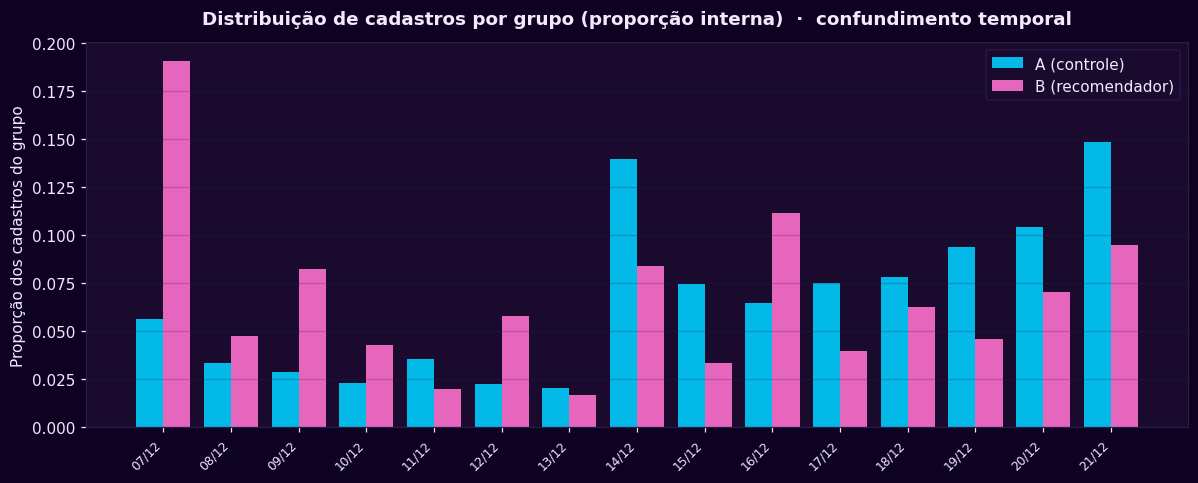

In [12]:
# GRÁFICO — Distribuição de cadastros por grupo (o confundimento temporal)
fig, ax = plt.subplots(figsize=(11, 4.5))
larg, x = 0.4, np.arange(len(prop))
ax.bar(x - larg/2, prop['A'].values, larg, label='A (controle)', color=cyan, alpha=0.9)
ax.bar(x + larg/2, prop['B'].values, larg, label='B (recomendador)', color=magenta, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([d.strftime('%d/%m') for d in prop.index], rotation=45, ha='right', fontsize=8)
ax.set_title('Distribuição de cadastros por grupo (proporção interna)  ·  confundimento temporal',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Proporção dos cadastros do grupo')
ax.legend(facecolor=panel_color, edgecolor=grid_color, labelcolor=text_color)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout(); plt.show()

### AED — distribuição temporal de cadastros

Os grupos **não** têm distribuição de cadastro equivalente:
- **B concentra cadastros no início** (07/12 = 19% de B vs 6% de A).
- **A concentra cadastros no fim** (21/12 = 15% de A vs 9% de B).

Implicações:
- B teve janela de observação mais longa (entrou cedo, dados vão até 30/12).
- A massa de A (cadastrada ~21/12) pega a `Christmas&New Year Promo` (início 25/12)
  dentro da janela de conversão; a massa de B já estava madura quando a promo começou.
- **Conclusão:** a comparação A vs B está confundida por tempo de cadastro. Os vieses de
  janela e de promo atingem os grupos de forma desigual → resultado do z-test deve ser
  lido com forte ressalva.

### Decisão sobre a janela de observação `[autoral]`

A spec pede conversão "em até 14 dias após o cadastro", mas os dados úteis terminam em
29/12. Quem se cadastrou perto de 21/12 nunca teve 14 dias completos de observação.

Duas alternativas:
- **Opção 1** — descartar quem não completa 14 dias. Rigoroso, mas elimina boa parte de
  uma amostra já pequena (655 no grupo B).
- **Opção 2** — aceitar a **janela truncada uniforme**, usando os eventos disponíveis até
  29/12, contanto que o truncamento atinja A e B de forma comparável.

**Decisão: Opção 2**, pela inviabilidade prática da Opção 1 com esta amostra — com a
ressalva explícita, registrada nas conclusões, de que a janela de 14 dias não pôde ser
respeitada. A verificação de comparabilidade entre grupos é feita acima (distribuição
de cadastros), que revelou o confundimento temporal.

In [13]:
# Eventos APENAS dos participantes válidos (UE, sem contaminação)
base_events = events[events['user_id'].isin(base['user_id'])].merge(
    base[['user_id', 'group']], on='user_id', how='left'
)

# (1) Eventos por usuário — distribuído igualmente entre A e B?
ev_per_user = base_events.groupby(['group', 'user_id']).size()
print('Eventos por usuário (média e mediana):')
print(ev_per_user.groupby('group').agg(['mean', 'median', 'count']), '\n')

# (2) Usuários de AMBAS as amostras estão presentes nos eventos?
print('Participantes com ao menos 1 evento, por grupo:')
print(base_events.groupby('group')['user_id'].nunique(), '\n')
print('Total de participantes por grupo (base):')
print(base['group'].value_counts(), '\n')

# (3) Eventos por dia
print('Eventos por dia:')
print(base_events.groupby(base_events['event_dt'].dt.date).size())

Eventos por usuário (média e mediana):
           mean  median  count
group                         
A      6.837545       6   1939
B      5.650382       5    655 

Participantes com ao menos 1 evento, por grupo:
group
A    1939
B     655
Name: user_id, dtype: int64 

Total de participantes por grupo (base):
A    1939
B     655
Name: group, dtype: int64 

Eventos por dia:
event_dt
2020-12-07     489
2020-12-08     408
2020-12-09     532
2020-12-10     428
2020-12-11     379
2020-12-12     423
2020-12-13     336
2020-12-14     948
2020-12-15     944
2020-12-16    1023
2020-12-17    1069
2020-12-18    1108
2020-12-19    1316
2020-12-20    1337
2020-12-21    1750
2020-12-22    1090
2020-12-23     864
2020-12-24     742
2020-12-26     491
2020-12-27     513
2020-12-28     395
2020-12-29     372
2020-12-30       2
dtype: int64


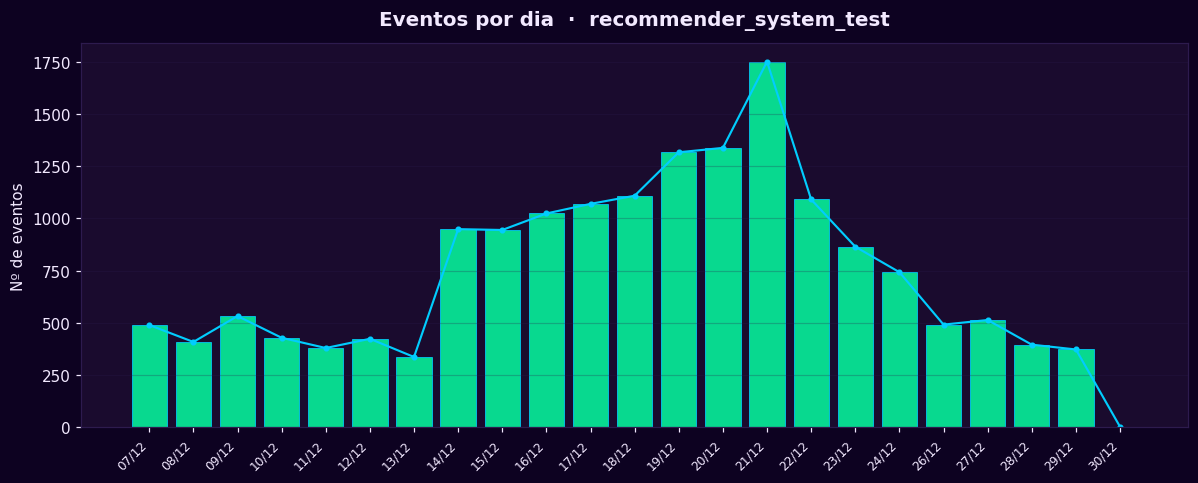

In [14]:
# GRÁFICO — Eventos por dia
daily_events = base_events.groupby(base_events['event_dt'].dt.date).size()

fig, ax = plt.subplots(figsize=(11, 4.5))
x = range(len(daily_events))
ax.bar(x, daily_events.values, color=mint, alpha=0.85, edgecolor=cyan, linewidth=0.6)
ax.plot(x, daily_events.values, color=cyan, linewidth=1.4, marker='o', markersize=3)
ax.set_xticks(list(x))
ax.set_xticklabels([d.strftime('%d/%m') for d in daily_events.index], rotation=45, ha='right', fontsize=8)
ax.set_title('Eventos por dia  ·  recommender_system_test', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Nº de eventos'); ax.grid(axis='y', alpha=0.25)
plt.tight_layout(); plt.show()

### AED — eventos, presença e distribuição por dia

- **Eventos por usuário:** A (média 6,84) é ~20% mais ativo que B (média 5,65) → mais um
  sinal de que os grupos não são plenamente comparáveis.
- **Presença:** 100% dos participantes válidos geraram ao menos um evento em ambos os
  grupos (ponto positivo — sem usuários fantasma).
- **Eventos por dia:** pico em 21/12 (fim da captação), sem eventos em 25/12 (Natal),
  e queda a ~zero em 30/12. Janela de observação útil termina em **29/12**, não em 01/01.

In [15]:
# Conjunto de usuários únicos que atingiram cada etapa, por grupo
steps = ['product_page', 'product_cart', 'purchase']

funnel = {}
for g in ['A', 'B']:
    total_g = base[base['group'] == g]['user_id'].nunique()
    line = {'total_usuarios': total_g}
    for step in steps:
        step_users = base_events[
            (base_events['group'] == g) & (base_events['event_name'] == step)
        ]['user_id'].nunique()
        line[step] = step_users
        line[f'{step}_conv'] = round(step_users / total_g, 4)
    funnel[g] = line

funnel_df = pd.DataFrame(funnel).T
print(funnel_df)

   total_usuarios  product_page  product_page_conv  product_cart  \
A          1939.0        1265.0             0.6524         589.0   
B           655.0         367.0             0.5603         184.0   

   product_cart_conv  purchase  purchase_conv  
A             0.3038     613.0         0.3161  
B             0.2809     191.0         0.2916  


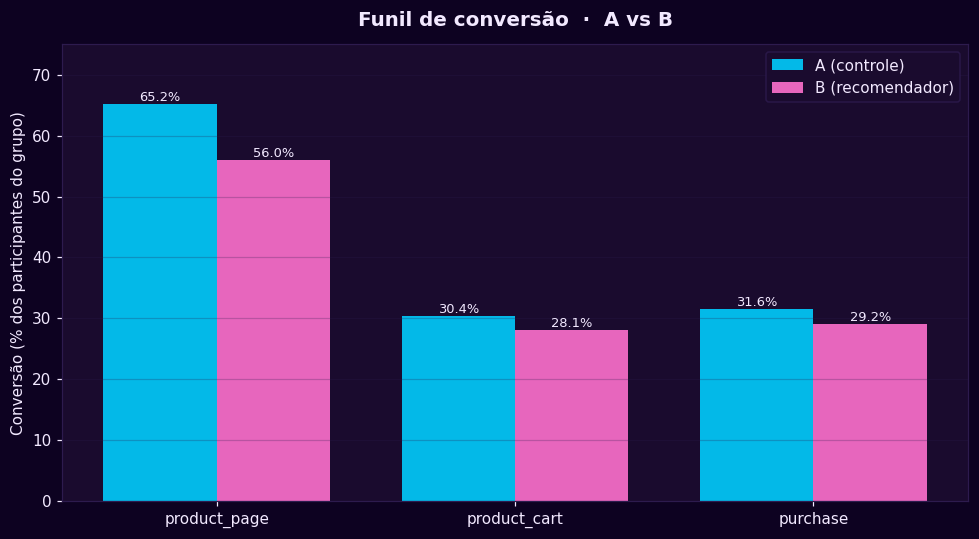

In [16]:
# GRÁFICO — Funil de conversão A vs B
conv_steps = ['product_page_conv', 'product_cart_conv', 'purchase_conv']
conv_a = funnel_df.loc['A', conv_steps].values.astype(float) * 100
conv_b = funnel_df.loc['B', conv_steps].values.astype(float) * 100

fig, ax = plt.subplots(figsize=(9, 5))
larg, x = 0.38, np.arange(len(conv_steps))
b1 = ax.bar(x - larg/2, conv_a, larg, label='A (controle)', color=cyan, alpha=0.9)
b2 = ax.bar(x + larg/2, conv_b, larg, label='B (recomendador)', color=magenta, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(['product_page', 'product_cart', 'purchase'], fontsize=10)
ax.set_ylabel('Conversão (% dos participantes do grupo)')
ax.set_title('Funil de conversão  ·  A vs B', fontsize=13, fontweight='bold', pad=12)
ax.legend(facecolor=panel_color, edgecolor=grid_color, labelcolor=text_color)
ax.grid(axis='y', alpha=0.25); ax.set_ylim(0, 75)
for bars in (b1, b2):
    for b in bars:
        ax.annotate(f'{b.get_height():.1f}%', (b.get_x()+b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontsize=8.5)
plt.tight_layout(); plt.show()

### AED — funil de conversão por grupo `[autoral]`

**Decisão:** conversão calculada sobre o total de participantes de cada grupo
(funil não-sequencial), e não em cascata etapa-a-etapa.

| Etapa          |   A    |   B    | B − A     |
|----------------|--------|--------|-----------|
| product_page   | 65,24% | 56,03% | −9,2 p.p. |
| product_cart   | 30,38% | 28,09% | −2,3 p.p. |
| purchase       | 31,61% | 29,16% | −2,5 p.p. |

**B ficou abaixo de A em todas as etapas** — oposto da hipótese (B ≥ A + 10%).
Em ambos os grupos, purchase > product_cart, confirmando funil não-sequencial.

## Passo 6 — Teste A/B (z-test)

In [17]:
alpha = 0.05 / 3   # Bonferroni para 3 comparações

def z_test_prop(successes_a, n_a, successes_b, n_b, step):
    p_a = successes_a / n_a
    p_b = successes_b / n_b
    p_pool = (successes_a + successes_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
    z = (p_a - p_b) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    print(f'{step}:')
    print(f'  A={p_a:.4f}  B={p_b:.4f}  z={z:.4f}  p={p_value:.4f}  '
          f'{"REJEITA H0" if p_value < alpha else "não rejeita H0"}')
    return p_value

n_a = 1939
n_b = 655
print(f'alpha (Bonferroni) = {alpha:.4f}\n')

z_test_prop(1265, n_a, 367, n_b, 'product_page')
z_test_prop(589,  n_a, 184, n_b, 'product_cart')
z_test_prop(613,  n_a, 191, n_b, 'purchase')

alpha (Bonferroni) = 0.0167

product_page:
  A=0.6524  B=0.5603  z=4.2186  p=0.0000  REJEITA H0
product_cart:
  A=0.3038  B=0.2809  z=1.1054  p=0.2690  não rejeita H0
purchase:
  A=0.3161  B=0.2916  z=1.1741  p=0.2404  não rejeita H0


0.24035836270660704

### Resultado do z-test

**Correção de comparações múltiplas `[autoral]`:** três testes → α de Bonferroni =
0,05/3 = **0,0167**, fixado antes de olhar os p-valores.

**Hipóteses:** H₀: p_A = p_B  ·  H₁: p_A ≠ p_B (bicaudal)

| Etapa         | p-valor | Decisão        | Direção |
|---------------|---------|----------------|---------|
| product_page  | 0,0000  | Rejeita H₀     | A > B   |
| product_cart  | 0,2690  | Não rejeita H₀ | —       |
| purchase      | 0,2404  | Não rejeita H₀ | —       |

A hipótese (B ≥ A + 10%) não se confirmou em nenhuma etapa. A única diferença
significativa (`product_page`) é **a favor do controle**. Carrinho e compra sem diferença detectável.

## Passo 7 — Conclusões

### Resultado nominal do teste
O grupo B (novo sistema de recomendação) **não superou** o grupo A em nenhuma etapa do
funil. A única diferença estatisticamente significativa (`product_page`, p < 0,0001) foi
**a favor do controle**. A hipótese de ganho de ≥10% por etapa não se confirmou.

### Por que este resultado NÃO deve ser tomado como definitivo `[autoral]`
O teste apresenta falhas graves de condução que comprometem a validade da comparação:

1. **Amostra insuficiente:** 2594 participantes válidos vs ~6000 esperados (−57%);
   grupo B com apenas 655 usuários → baixo poder estatístico.
2. **Desbalanceamento estrutural:** alocação ~75/25 (A/B), persistente após todos os
   cortes — atípica e não explicada pela especificação.
3. **Contaminação cruzada:** 24% dos participantes originais também estavam no
   `interface_eu_test`, rodando no mesmo público e período (removidos, mas evidencia
   má gestão de experimentos simultâneos).
4. **Confundimento temporal:** B concentrou cadastros no início do período e A no fim,
   gerando janelas de observação desiguais e exposição diferente à promo de Natal.
5. **Janela de 14 dias não cumprida:** dados úteis terminam em 29/12; usuários tardios
   nunca tiveram os 14 dias completos de observação.
6. **Fator externo não controlado:** `Christmas&New Year Promo` (EU) ativa nos últimos
   dias da janela, afetando a conversão de forma não uniforme entre grupos.

### Recomendação
**Não implementar o novo sistema de recomendação com base neste teste.** Os dados não
sustentam o ganho esperado — e, mais importante, o teste está comprometido demais para
uma decisão confiável em qualquer direção. Recomenda-se **repetir o experimento** com:
alocação balanceada, amostra completa (~6000), isolamento de outros testes simultâneos,
janela livre de campanhas de marketing, e período que garanta os 14 dias de observação
a todos os participantes.